In [1]:
from __future__ import annotations

In [2]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

In [4]:
import os
import datetime
import numpy as np
import sklearn.metrics
import sklearn.datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set_theme(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [5]:
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.is_available())

CUDA: 12.8
GPU: True


In [6]:
rng = np.random.default_rng()

In [7]:
def plot_grid(X, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    imgs = X[rng.choice(np.arange(X.shape[0]), size=ax.shape)].reshape(*ax.shape, 28, 28)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [8]:
def plot_grid_and_label(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=True, label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])
    
    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)
        
    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])
        
    preds = np.argmax(model.predict(inputs), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [9]:
label_description = [
     'A',   'I',   'U',  'E',  'O',
    'KA',  'KI',  'KU', 'KE', 'KO',
    'SA', 'SHI',  'SU', 'SE', 'SO',
    'TA', 'CHI', 'TSU', 'TE', 'TO',
    'NA',  'NI',  'NU', 'NE', 'NO',
    'HA',  'HI',  'FU', 'HE', 'HO',
    'MA',  'MI',  'MU', 'ME', 'MO',
    'YA',         'YU',       'YO',
    'RA',  'RI',  'RU', 'RE', 'RO',
    'WA',  'II',        'EE', 'WO',
     'N',  'IT'
]

In [10]:
X, y = sklearn.datasets.fetch_openml('Kuzushiji-49', version=1, return_X_y=True, as_frame=False, parser='auto')
y = np.array(list(map(int, y)))
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=49)

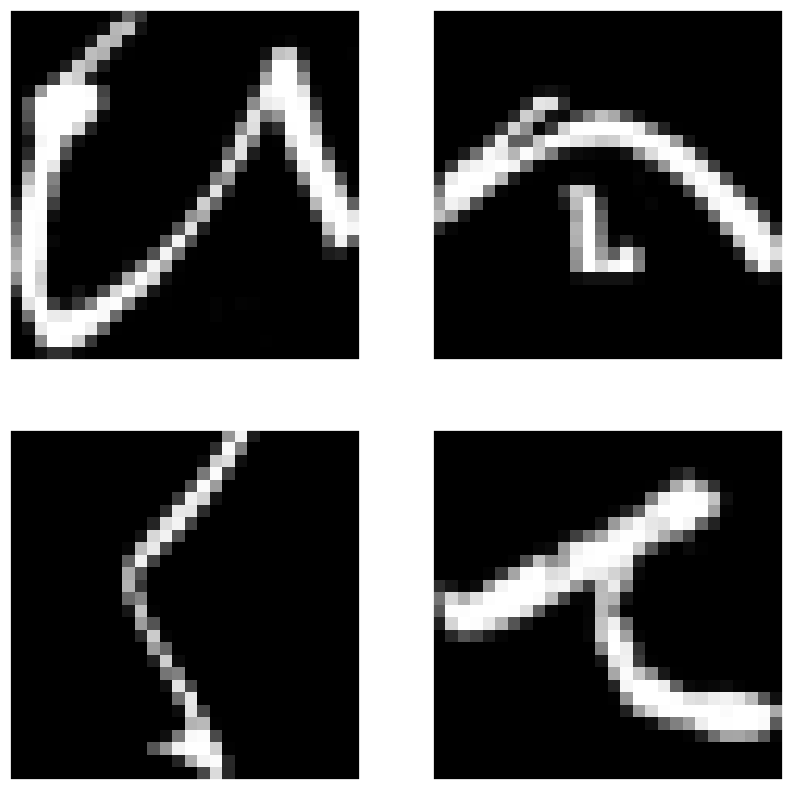

In [11]:
plot_grid(X_train)

In [12]:
counts = { j: np.sum(y_train == i) for i, j in enumerate(label_description) }

In [13]:
sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

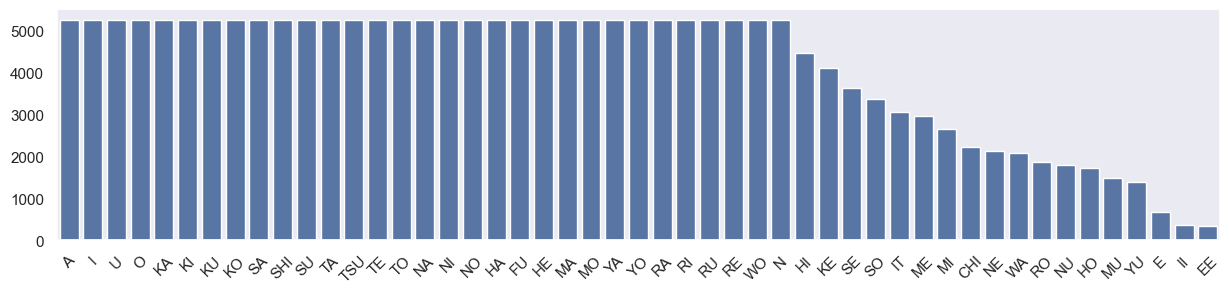

In [14]:
plt.figure(figsize=(15, 3))
sns.barplot(x=list(sorted_counts.keys()), y=list(sorted_counts.values()))
plt.xticks(rotation=45)
plt.show()

In [15]:
rare_classes = [label_description.index(i) for i in list(sorted_counts.keys())[-18:]]

In [16]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.arange(49), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

In [17]:
img_len = X_train[0].shape[0]
img_len, np.sqrt(img_len)

(784, np.float64(28.0))

## Flattened images
Use Dense layers

In [18]:
# create train and validation datasets, these datasets should use flattened images
X_train.shape

(203184, 784)

In [19]:
x = inputs = keras.layers.Input(shape=(784,))
x = keras.layers.Rescaling(1./255)(x)

x = keras.layers.Dense(512, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.4)(x)

x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.2)(x)

x = keras.layers.Dense(49, activation='softmax')(x)

In [20]:
model = keras.models.Model(inputs=inputs, outputs=x)

In [21]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 576,049 (2.20 MB)

 Trainable params: 574,257 (2.19 MB)

 Non-trainable params: 1,792 (7.00 KB)

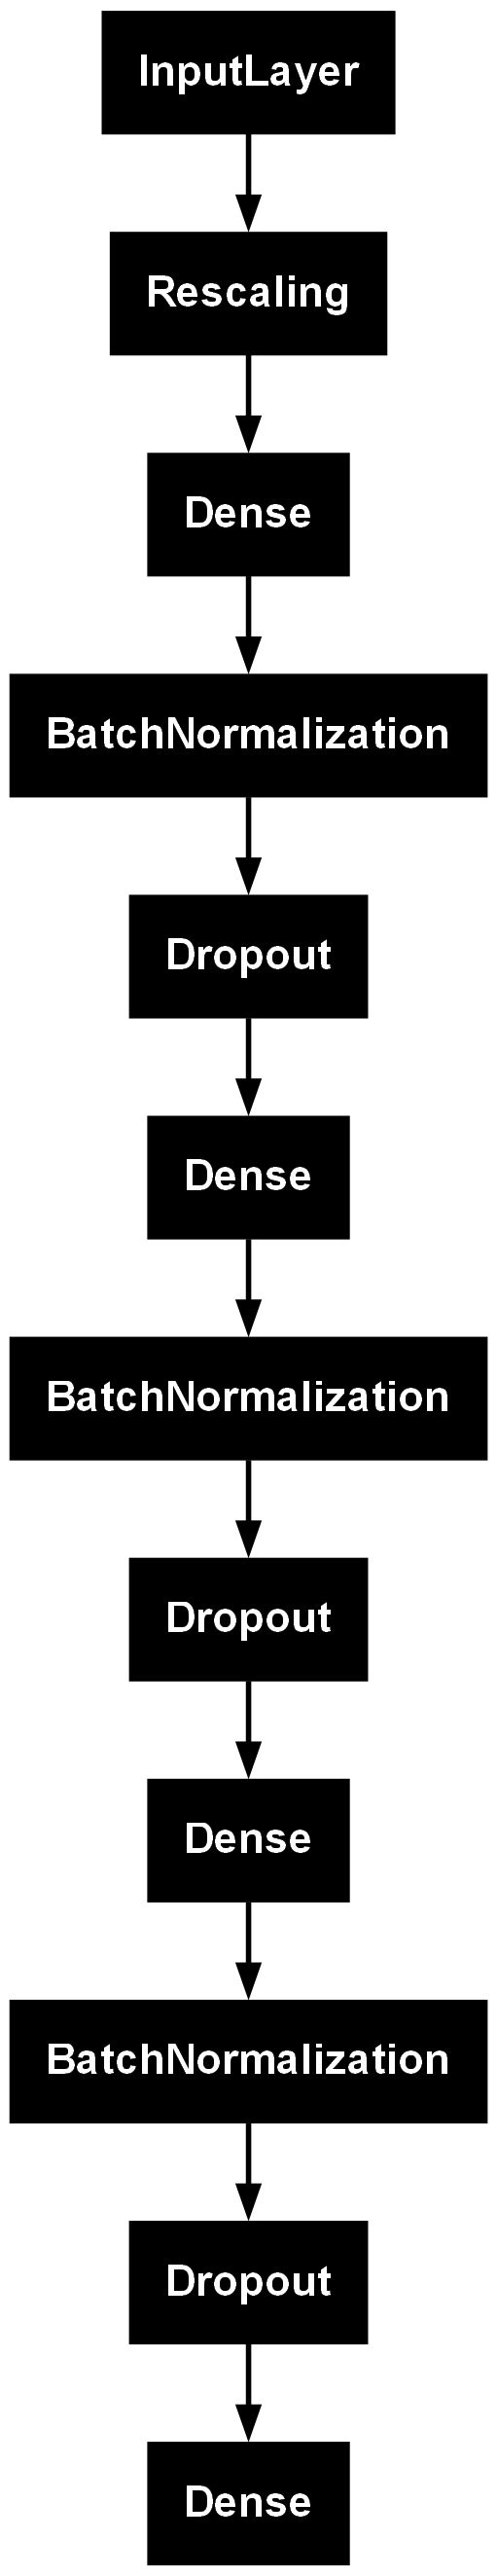

In [22]:
keras.utils.plot_model(model)

In [23]:
logdir = os.path.join('logs/kuzushiji-49/', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

In [24]:
model_dir = os.path.join(logdir, "model.keras")

In [25]:
callbacks = [
    keras.callbacks.ModelCheckpoint(model_dir, save_best_only=True, monitor='val_loss'),
    keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [26]:
# compile the model, make sure to add accuracy metric
model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
# train the model, make sure to use callbacks and validation dataset
model.fit(X_train, y_train, batch_size=1024, epochs=10, validation_split=0.2, class_weight=class_weight_dict, callbacks=callbacks)

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.5105 - loss: 1.9250 - val_accuracy: 0.6820 - val_loss: 1.4364
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.6911 - loss: 1.1346 - val_accuracy: 0.7869 - val_loss: 0.8240
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.7414 - loss: 0.9198 - val_accuracy: 0.8269 - val_loss: 0.6452
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.7714 - loss: 0.8040 - val_accuracy: 0.8422 - val_loss: 0.5765
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.7914 - loss: 0.7199 - val_accuracy: 0.8538 - val_loss: 0.5334
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8055 - loss: 0.6665 - val_accuracy: 0.8614 - val_loss: 0.5022
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8160 - loss: 0.6248 - val_accuracy: 0.8682 - val_loss: 0.4781
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8245 - loss: 0.5902 - val_accu

In [28]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


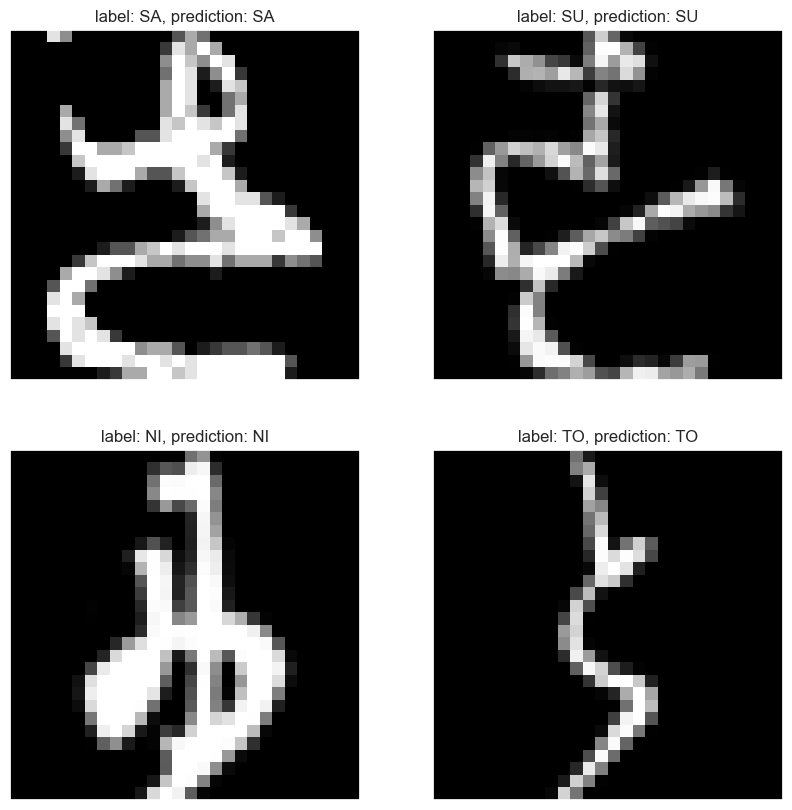

In [29]:
plot_grid_and_label(images, y_test, model, label_description=label_description)

In [30]:
y_pred_probs = model.predict(X_test, batch_size=512)
y_pred = np.argmax(y_pred_probs, axis=1)

133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


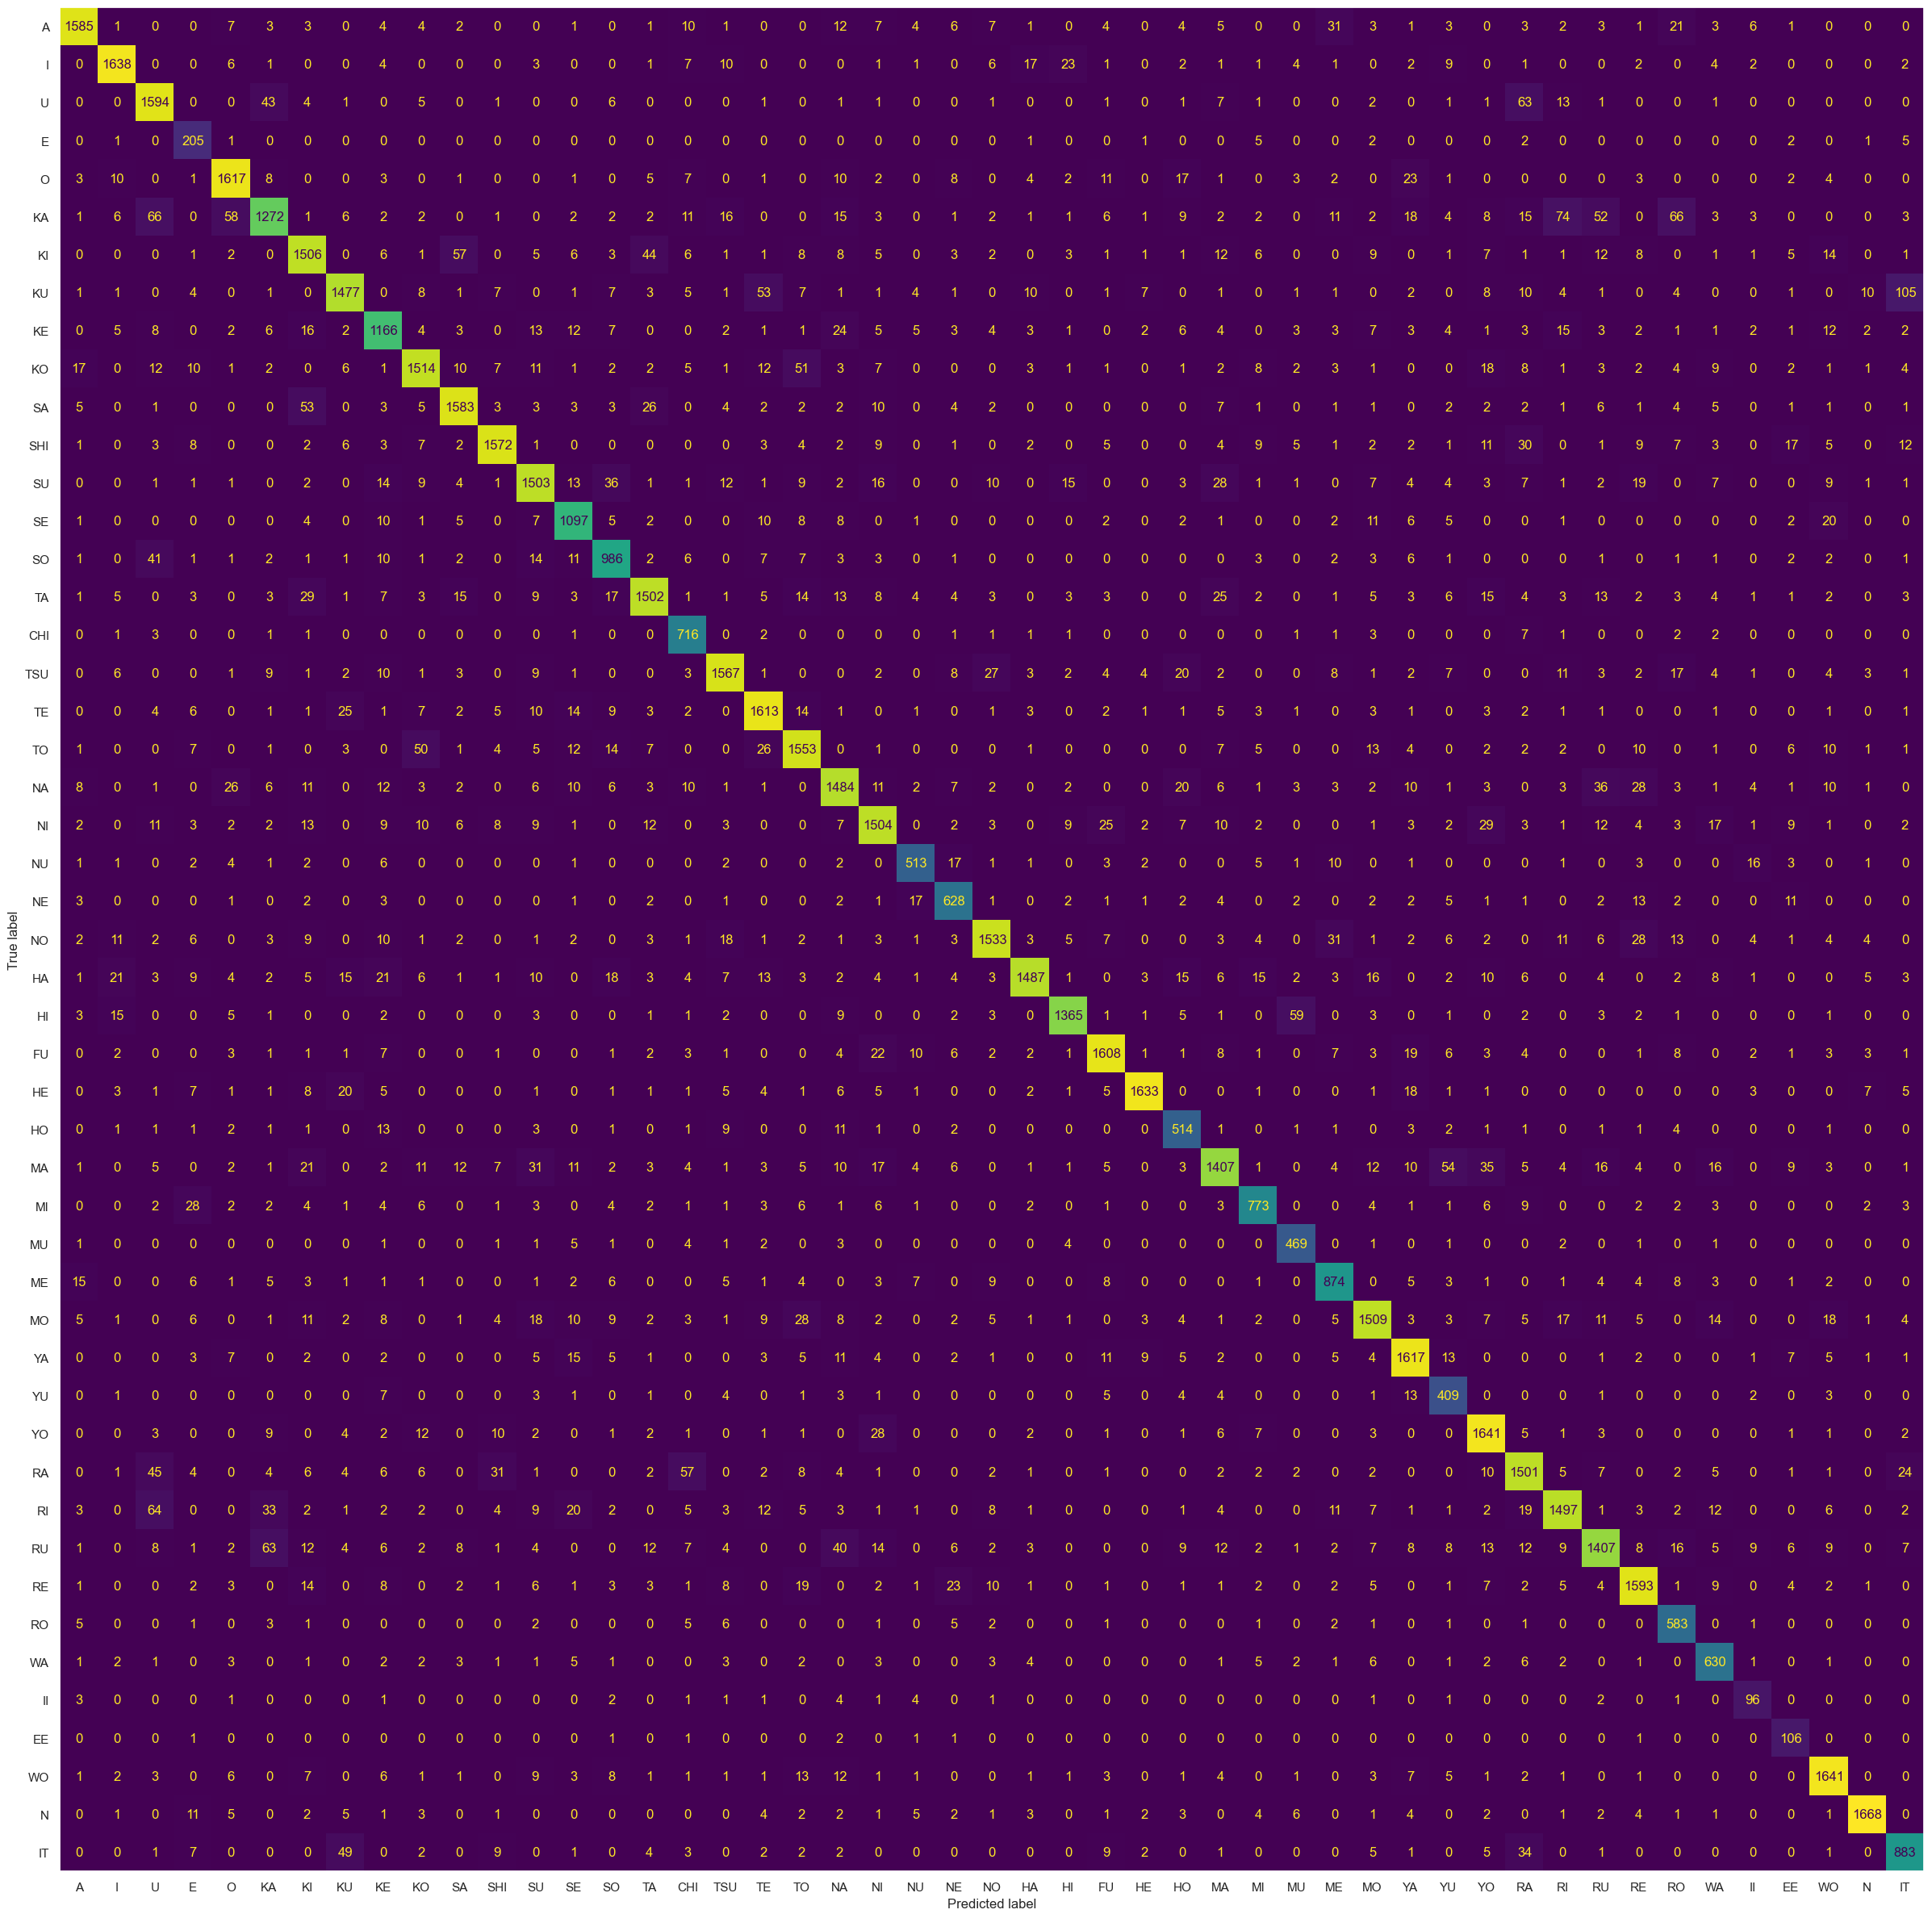

In [31]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [32]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.8851342262292381)

## Actual images
Use Conv2D layers with Dense layer on top

In [33]:
# create train and validation datasets, these datasets should use 28x28x1 images
X_train_image, X_test_image = X_train.reshape((-1, 28, 28)), X_test.reshape((-1, 28, 28))

In [34]:
# create model, this model should accept a 28x28x1 image
x = inputs = keras.layers.Input((28, 28, 1))
x = keras.layers.Rescaling(1./255)(x)

x = keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.25)(x)

x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = keras.layers.MaxPooling2D(2)(x)
x = keras.layers.Dropout(0.25)(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(49, activation='softmax')(x)

In [35]:
model = keras.models.Model(inputs=inputs, outputs=x)

In [36]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 473,745 (1.81 MB)

 Trainable params: 473,297 (1.81 MB)

 Non-trainable params: 448 (1.75 KB)

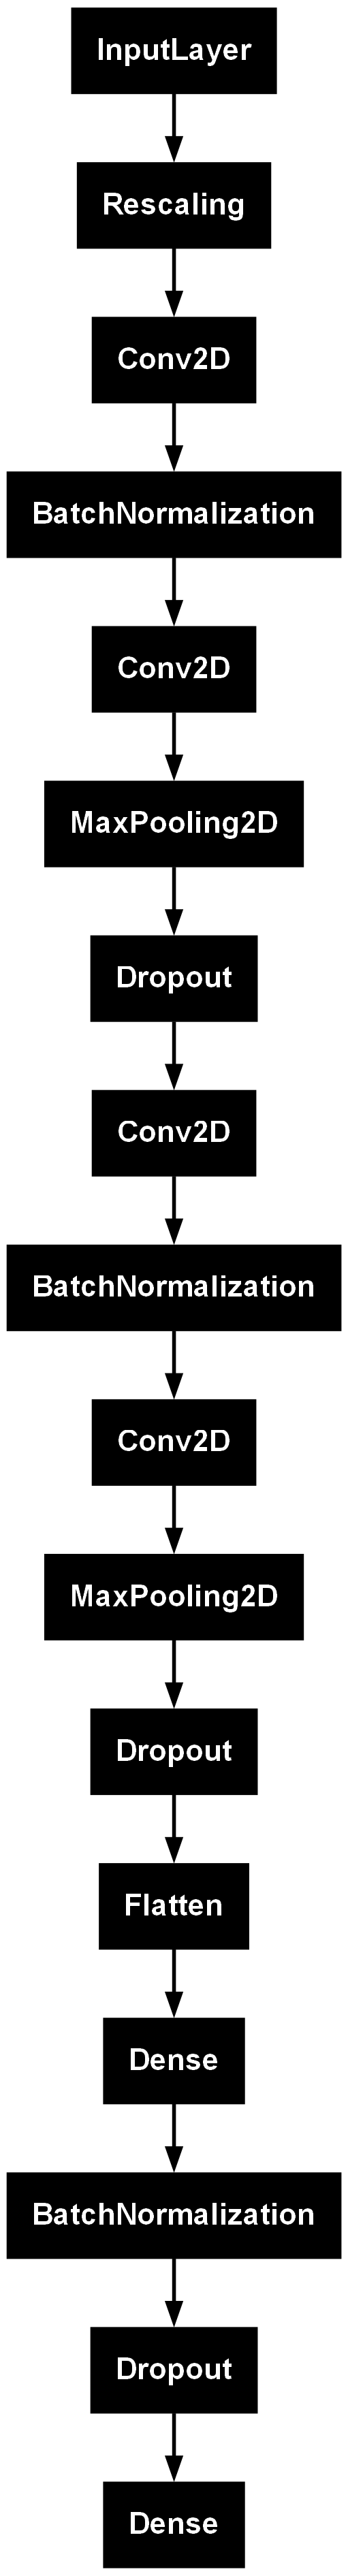

In [37]:
keras.utils.plot_model(model)

In [38]:
logdir = os.path.join('logs/kuzushiji-49/', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
model_dir = os.path.join(logdir, "model.keras")

In [39]:
callbacks = [
    keras.callbacks.ModelCheckpoint(model_dir, save_best_only=True, monitor='val_loss'),
    keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [40]:
# compile the model, make sure to add accuracy metric
model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
# train the model, make sure to use callbacks and validation dataset
model.fit(X_train_image, y_train, batch_size=1024, epochs=10, validation_split=0.2, class_weight=class_weight_dict, callbacks=callbacks)

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.5795 - loss: 1.6674 - val_accuracy: 0.0148 - val_loss: 5.0285
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.8045 - loss: 0.7315 - val_accuracy: 0.1095 - val_loss: 2.8205
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.8617 - loss: 0.5061 - val_accuracy: 0.8455 - val_loss: 0.6694
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8873 - loss: 0.4019 - val_accuracy: 0.9301 - val_loss: 0.2730
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.9034 - loss: 0.3391 - val_accuracy: 0.9447 - val_loss: 0.2028
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9130 - loss: 0.3010 - val_accuracy: 0.9508 - val_loss: 0.1823
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.9200 - loss: 0.2737 - val_accuracy: 0.9528 - val_loss: 0.1761
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.9266 - loss: 0.2508 

In [42]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


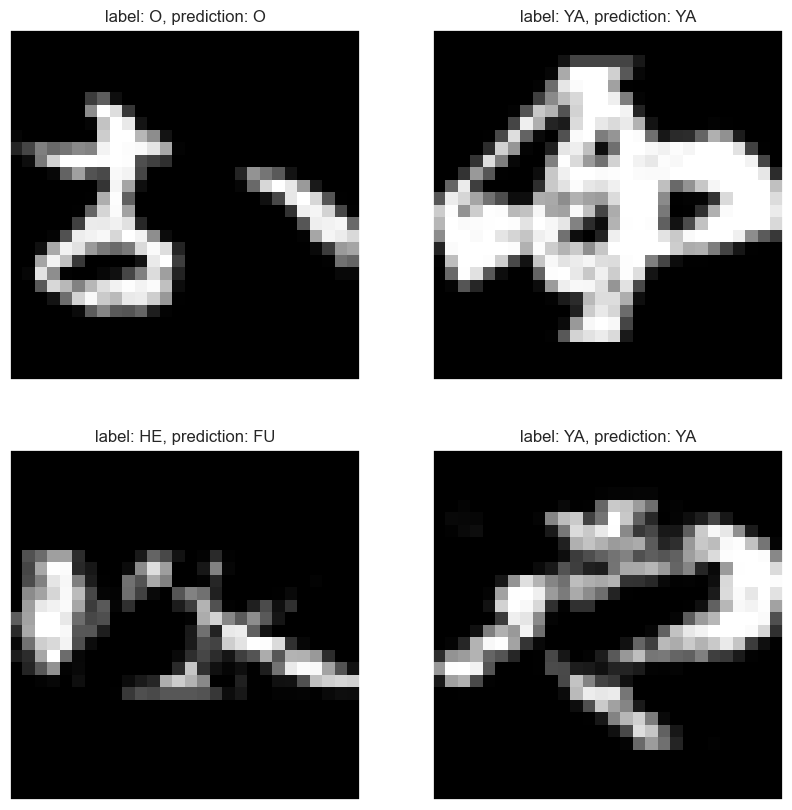

In [43]:
plot_grid_and_label(images, y_test, model, label_description=label_description, flatten_image=False)

In [44]:
y_pred_probs = model.predict(X_test_image, batch_size=512)
y_pred = np.argmax(y_pred_probs, axis=1)

133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


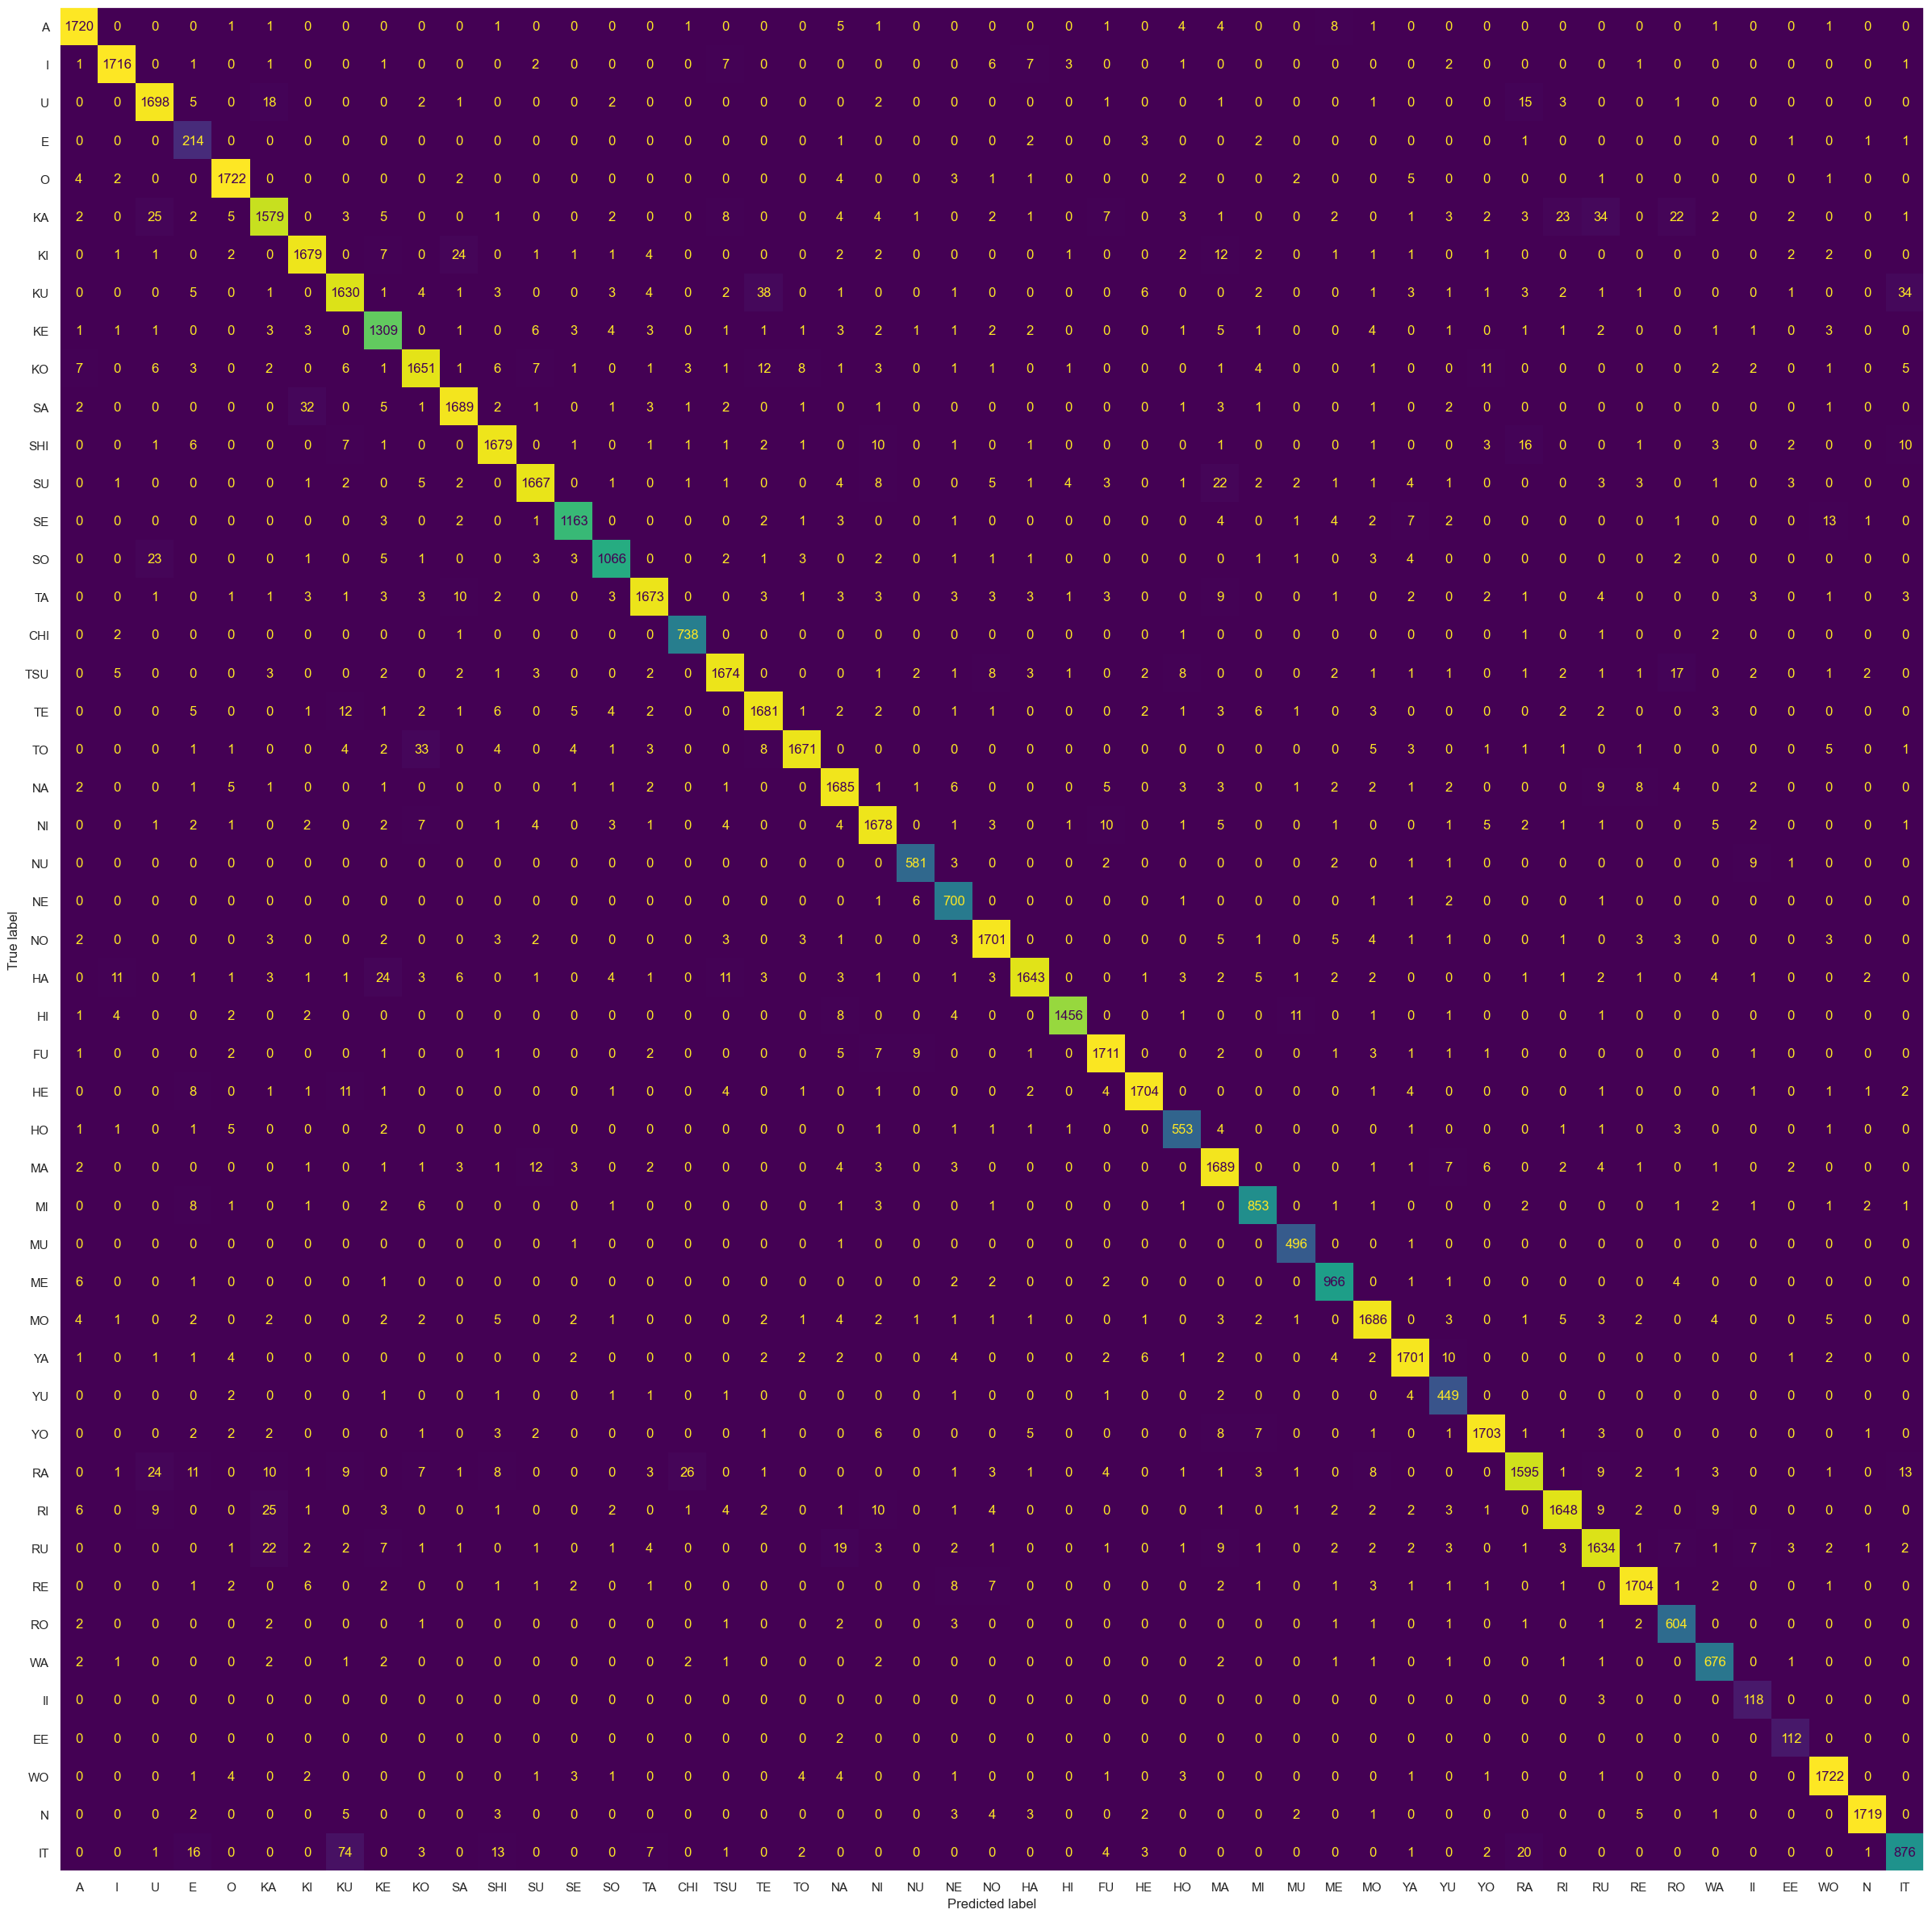

In [45]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [46]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.9608030373357721)

##### Rare classes

In [47]:
rare_classes_accuracy = []
for c in rare_classes:
    mask = y_test == c
    acc = np.mean(y_test[mask] == y_pred[mask])
    rare_classes_accuracy.append(acc)
    print(f"Class {c}: accuracy = {acc:.3f}")

Class 26: accuracy = 0.976
Class 8: accuracy = 0.955
Class 13: accuracy = 0.960
Class 14: accuracy = 0.948
Class 48: accuracy = 0.855
Class 33: accuracy = 0.980
Class 31: accuracy = 0.958
Class 16: accuracy = 0.989
Class 23: accuracy = 0.982
Class 43: accuracy = 0.970
Class 42: accuracy = 0.971
Class 22: accuracy = 0.968
Class 29: accuracy = 0.955
Class 32: accuracy = 0.994
Class 36: accuracy = 0.968
Class 3: accuracy = 0.947
Class 44: accuracy = 0.975
Class 45: accuracy = 0.982


In [48]:
np.array(rare_classes_accuracy).mean()

np.float64(0.9630749349696018)

In [49]:
print(f"Примеров редкого класса в валидации: {np.sum(y_test == 45)}")

Примеров редкого класса в валидации: 114
